# This Section Concerns all mentioned Datasets with Random Forest

# Imports

In [ ]:
# Standard library
import os

# Data handling
import numpy as np
import pandas as pd
from scipy import sparse

# GPU libraries (optional for cuML models)
import cupy as cp
from cuml.ensemble import RandomForestClassifier


# ML utilities
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve
)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

def to_gpu_dense(X):
    """
    Converts input matrix X into a dense CuPy array safely.
    - If X is SciPy CSR/CSC/COO sparse → convert to NumPy dense → CuPy
    - If X is pandas DataFrame → convert to NumPy → CuPy
    - If X is NumPy array → CuPy
    - Never return nested object-arrays
    """

    # Case 1: SciPy sparse (CSR, CSC, COO)
    if sparse.issparse(X):
        # Convert sparse → dense NumPy → CuPy
        X_np = X.toarray().astype(np.float32)
        return cp.asarray(X_np)

    # Case 2: Pandas DataFrame
    if hasattr(X, "values"):
        return cp.asarray(X.values.astype(np.float32))

    # Case 3: NumPy array
    if isinstance(X, np.ndarray):
        return cp.asarray(X.astype(np.float32))

    # If it's already CuPy
    if isinstance(X, cp.ndarray):
        return X

    raise TypeError(f"Unsupported type passed to to_gpu_dense(): {type(X)}")

def load_split(data, split, base_path="../data/splits/"):
    """
    Loads X_train, X_test, y_train, y_test for a given dataset + split.
    Automatically detects whether features are stored as sparse (.npz)
    or dense (.csv).

    Example:
        X_train, X_test, y_train, y_test = load_split("cup98", "7030")
    """

    path = os.path.join(base_path, split)

    # ---- Load X_train ----
    npz_path = os.path.join(path, f"X_train_{data}.npz")
    csv_path = os.path.join(path, f"X_train_{data}.csv")

    if os.path.exists(npz_path):
        X_train = sparse.load_npz(npz_path)
    else:
        X_train = pd.read_csv(csv_path)

    # ---- Load X_test ----
    npz_path = os.path.join(path, f"X_test_{data}.npz")
    csv_path = os.path.join(path, f"X_test_{data}.csv")

    if os.path.exists(npz_path):
        X_test = sparse.load_npz(npz_path)
    else:
        X_test = pd.read_csv(csv_path)

    # ---- Load labels ----
    y_train = pd.read_csv(os.path.join(path, f"y_train_{data}.csv"))
    y_test  = pd.read_csv(os.path.join(path, f"y_test_{data}.csv"))

    # Convert DataFrames → Series
    y_train = y_train.iloc[:, 0]
    y_test  = y_test.iloc[:, 0]

    return X_train, X_test, y_train, y_test



def load_all_by_split(datasets, base_path="../data/splits/"):
    split_types = ["7030", "3070", "5050"]
    result = {split: {} for split in split_types}

    for split in split_types:
        print(f"\n=== Loading {split} splits ===")
        for data in datasets:
            print(f"  -> Loading {data}")
            X_train, X_test, y_train, y_test = load_split(data, split, base_path)
            result[split][data] = {
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test
            }

    return result

# Note on Using Breiman-Style Random Forest mtry Settings in cuML

Breiman’s original Random Forest formulation (Breiman, 2001) recommends selecting the 
number of features to consider at each split (`mtry`) as a function of the input 
dimensionality. In particular, the canonical guideline is:

\[
mtry \in \left\{ \frac{\sqrt{p}}{2},\ \sqrt{p},\ 2\sqrt{p},\ 4\sqrt{p},\ 8\sqrt{p} \right\}
\]

where \( p \) is the total number of features.

In classical CPU-based implementations, `mtry` can be specified as an **integer count**.  
However, **cuML’s RandomForestClassifier does not accept integer `max_features`**, and instead 
requires:

- A **float** in the range `(0, 1]`, representing the *fraction of the total feature space*, or  
- A preset string such as `"sqrt"` or `"log2"`

To implement Breiman-style scaling on GPU while staying faithful to the intended feature 
exposure per split, we convert each `mtry` value into a cuML-compatible fraction:

\[
\text{cuML\_max\_features} = \frac{mtry}{p}
\]

Thus, for a feature space of size \( p \), we compute:

\[
s = \lfloor \sqrt{p} \rfloor
\]

\[
mtry \in \left\{ \left\lfloor \frac{s}{2} \right\rfloor,\ s,\ 2s,\ 4s,\ 8s \right\}
\]

and use:

\[
\text{max\_features} = \frac{mtry}{p}
\]

This mapping preserves the **relative selection pressure** intended by Breiman’s formulation 
while maintaining compatibility with cuML’s API.

For each dataset, we therefore train **5 GPU-accelerated Random Forests**, each using:

- `n_estimators = 500`  
- `max_features = mtry / num_features`  
- `mtry ∈ {s/2, s, 2s, 4s, 8s}`, where `s = floor(sqrt(num_features))`

This configuration provides a more scalable and expressive mtry schedule than the fixed small 
values used in the Breiman–Cutler replication, and it generally yields stronger performance on 
both balanced and high-dimensional datasets while adhering to the theoretical motivation of 
Breiman’s Random Forests.


In [ ]:
def Tree_Training_Testing(data, mtry_values=None):

    """
    Trains multiple GPU RF models with Breiman-style mtry settings (Option B).

    Parameters:
        data: dict with "X_train", "y_train", "X_test", "y_test"
        mtry_values: optional list of integer feature counts

    Returns:
        results: dict mapping mtry → accuracy
    """

    # --- Convert X to GPU arrays ---
    X_train = to_gpu_dense(data["X_train"]).astype(cp.float32)
    X_test  = to_gpu_dense(data["X_test"]).astype(cp.float32)

    # --- Convert y to GPU arrays ---
    y_train = cp.asarray(data["y_train"]).astype(cp.int32)
    y_test  = cp.asarray(data["y_test"]).astype(cp.int32)
    y_test_cpu = cp.asnumpy(y_test)  

    num_features = X_train.shape[1]
    results = {}

    # --- Option B: Breiman-style mtry values ---
    if mtry_values is None:
        s = int(np.sqrt(num_features))
        mtry_values = [
            max(1, int(s/2)),
            s,
            2*s,
            4*s,
            8*s
        ]
        print("Using Breiman mtry:", mtry_values)

    print(f"Total features: {num_features}")


    for mtry in mtry_values:

        frac = mtry / num_features
        frac = min(max(frac, 1.0 / num_features), 1.0)

        print(f"\nTraining RF with mtry={mtry} → max_features={frac:.5f}")

        rf = RandomForestClassifier(
            n_estimators=500,
            max_depth=100,
            max_features=frac,
            n_streams=8
        )

        rf.fit(X_train, y_train)

        preds_cpu = cp.asnumpy(rf.predict(X_test))

        probs_cpu = cp.asnumpy(rf.predict_proba(X_test)[:, 1])

        acc = accuracy_score(y_test_cpu, preds_cpu)

        auc = roc_auc_score(y_test_cpu, probs_cpu)

        results[mtry] = acc
        print(f"Accuracy={acc:.4f}, AUC={auc:.4f}")

    return results


def evaluate_model(preds_gpu, y_test, title="Model Evaluation"):
    # Convert GPU → CPU
    preds = cp.asnumpy(preds_gpu)
    y_test_cpu = cp.asnumpy(y_test)

    # ======== Accuracy ========
    acc = accuracy_score(y_test_cpu, preds)
    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.4f}")

    # ======== Precision / Recall / F1 ========
    print("\nClassification Report:")
    print(classification_report(y_test_cpu, preds))

    # ======== Confusion Matrix ========
    cm = confusion_matrix(y_test_cpu, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======== ROC Curve (Binary only) ========
    if len(cp.unique(y_test)) == 2:  
        try:
            # AUC
            auc = roc_auc_score(y_test_cpu, preds)
            print(f"AUC: {auc:.4f}")

            # ROC curve
            fpr, tpr, _ = roc_curve(y_test_cpu, preds)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
            plt.plot([0,1], [0,1], 'k--')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curve: {title}")
            plt.legend()
            plt.show()
        except Exception as e:
            print("Could not compute ROC:", e)
    else:
        print("\nROC/AUC skipped (not binary classification).")

## Loading Data in

In [ ]:
datasets = ["wine", "cup98", "customer"]

all_splits = load_all_by_split(datasets)



=== Loading 7030 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 3070 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 5050 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer


# 30 70 Split

## Wine Data

Using Breiman mtry: [1, 3, 6, 12, 24]
Total features: 12

Training RF with mtry=1 → max_features=0.08333
Accuracy=0.9910, AUC=0.9980

Training RF with mtry=3 → max_features=0.25000
Accuracy=0.9930, AUC=0.9974

Training RF with mtry=6 → max_features=0.50000
Accuracy=0.9925, AUC=0.9981

Training RF with mtry=12 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963

Training RF with mtry=24 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963
Best mtry: 3

=== Wine (best mtry=3) ===
Accuracy: 0.9930

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3429
           1       0.99      0.98      0.99      1120

    accuracy                           0.99      4549
   macro avg       0.99      0.99      0.99      4549
weighted avg       0.99      0.99      0.99      4549



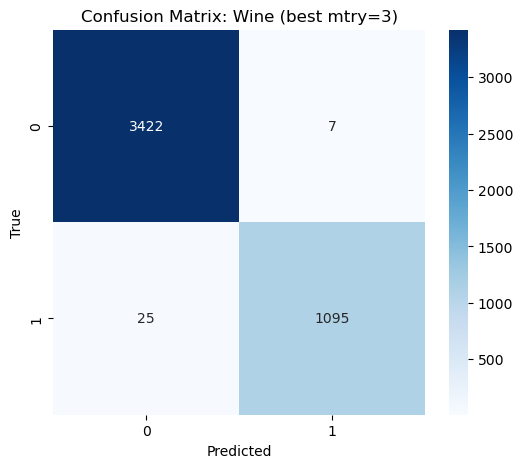

AUC: 0.9878


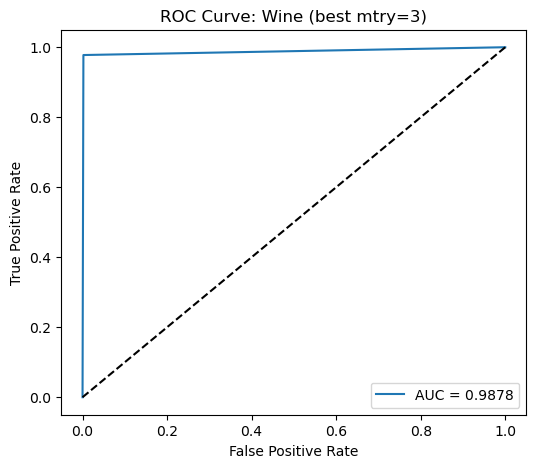

In [ ]:
wine_3070 = all_splits["3070"]["wine"]
results = Tree_Training_Testing(wine_3070)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Retrain using best mtry
num_features = wine_3070["X_train"].shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(wine_3070["X_train"].astype(cp.float32), wine_3070["y_train"])

# Predict (keep on GPU)
preds_gpu = best_rf.predict(wine_3070["X_test"].astype(cp.float32))

# Evaluate (GPU arrays)
evaluate_model(preds_gpu, wine_3070["y_test"], title=f"Wine (best mtry={best_mtry})")


## Customer Data

Using Breiman mtry: [1, 2, 4, 8, 16]
Total features: 7

Training RF with mtry=1 → max_features=0.14286
Accuracy=0.6929, AUC=0.7545

Training RF with mtry=2 → max_features=0.28571
Accuracy=0.6830, AUC=0.7559

Training RF with mtry=4 → max_features=0.57143
Accuracy=0.6794, AUC=0.7558

Training RF with mtry=8 → max_features=1.00000
Accuracy=0.6894, AUC=0.7577

Training RF with mtry=16 → max_features=1.00000
Accuracy=0.6894, AUC=0.7577
Best mtry: 1

=== Customer (best mtry=1) ===
Accuracy: 0.6929

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.73      0.68       640
           1       0.75      0.66      0.70       770

    accuracy                           0.69      1410
   macro avg       0.70      0.70      0.69      1410
weighted avg       0.70      0.69      0.69      1410



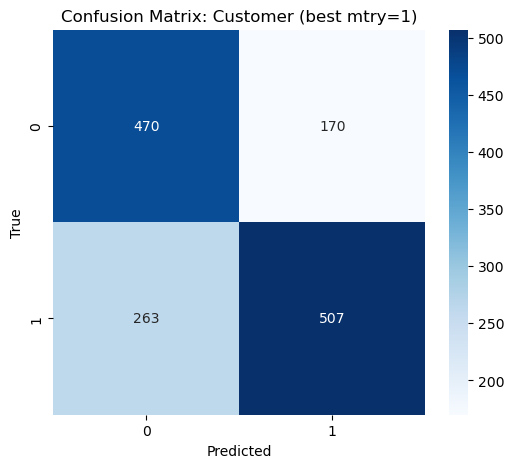

AUC: 0.6964


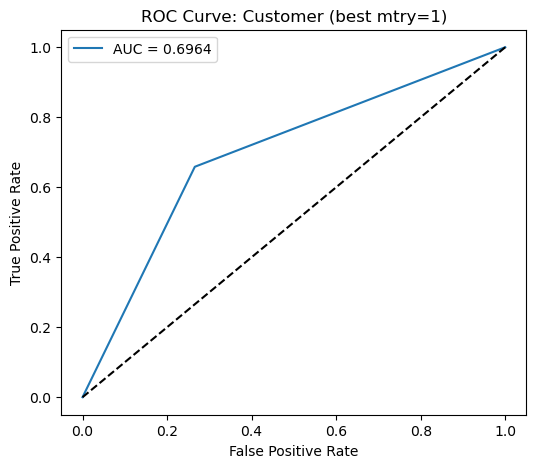

In [ ]:
customer_3070 = all_splits["3070"]["customer"]

X_train = customer_3070["X_train"].astype(cp.float32)
X_test = customer_3070["X_test"].astype(cp.float32)
y_train = customer_3070["y_train"]

# Step 1: Hyperparameter sweep (mtry)
results = Tree_Training_Testing(customer_3070)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Step 2: Fit best RF using scaled mtry for cuML
num_features = X_train.shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(X_train, y_train)

# Step 3: Predict (keep on GPU)
preds_gpu = best_rf.predict(X_test)

# Step 4: Evaluate (GPU arrays)
evaluate_model(preds_gpu, customer_3070["y_test"], title=f"Customer (best mtry={best_mtry})")

## Cup98

Train class distribution: (array([0, 1], dtype=int32), array([27170,  1452]))
Test class distribution: (array([0, 1], dtype=int32), array([63399,  3391]))
Using Breiman mtry: [29, 58, 116, 232, 464]
Total features: 3451

Training RF with mtry=29 → max_features=0.00840
Accuracy=0.9492, AUC=0.5686

Training RF with mtry=58 → max_features=0.01681
Accuracy=0.9492, AUC=0.5720

Training RF with mtry=116 → max_features=0.03361
Accuracy=0.9492, AUC=0.5680

Training RF with mtry=232 → max_features=0.06723
Accuracy=0.9492, AUC=0.5681

Training RF with mtry=464 → max_features=0.13445
Accuracy=0.9492, AUC=0.5649
Best mtry: 29

Best threshold from PR-curve: 0.06182784

Confusion Matrix:
[[45301 18098]
 [ 2097  1294]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     63399
           1       0.07      0.38      0.11      3391

    accuracy                           0.70     66790
   macro avg       0.51      0.55      0.47 

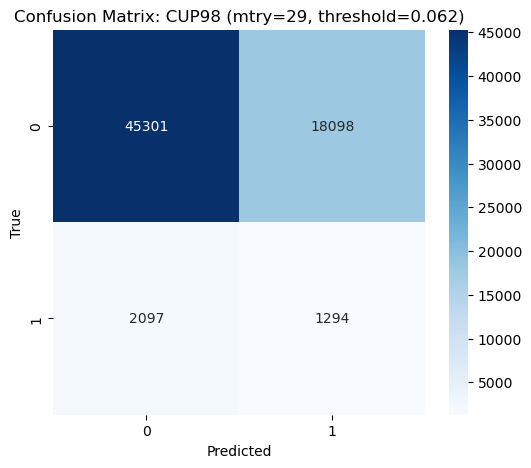

AUC: 0.5481


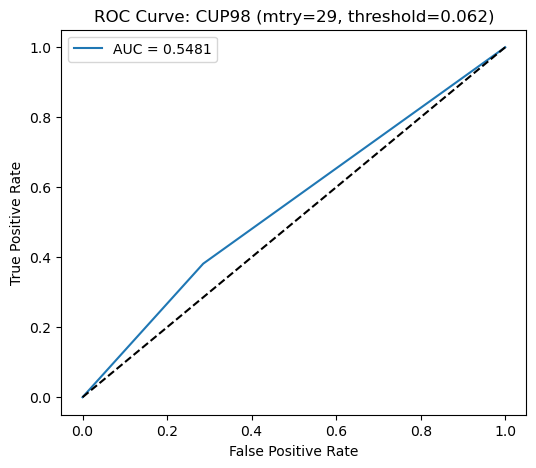

In [ ]:
import cupy as cp
import numpy as np
from cuml.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix

cup98_3070 = all_splits["3070"]["cup98"]

X_train_dense = to_gpu_dense(cup98_3070["X_train"]).astype(cp.float32)
X_test_dense  = to_gpu_dense(cup98_3070["X_test"]).astype(cp.float32)

y_train = cp.asarray(cup98_3070["y_train"].to_numpy(), dtype=cp.int32)
y_test  = cp.asarray(cup98_3070["y_test"].to_numpy(), dtype=cp.int32)

cup98_data_dense = {
    "X_train": X_train_dense,
    "y_train": y_train,
    "X_test": X_test_dense,
    "y_test": y_test,
}

print("Train class distribution:", cp.unique(y_train, return_counts=True))
print("Test class distribution:", cp.unique(y_test, return_counts=True))

try:
    results = Tree_Training_Testing(cup98_data_dense)
    best_mtry = max(results, key=results.get)
except:
    best_mtry = int(np.sqrt(X_train_dense.shape[1]))
    print(f"Using fallback mtry={best_mtry}")

print("Best mtry:", best_mtry)


num_features = X_train_dense.shape[1]
max_feat_fraction = min(1.0, best_mtry / num_features)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=100,          # leave very big for unlimited
    max_features=max_feat_fraction,
    n_streams=8
)

best_rf.fit(X_train_dense, y_train)

probs_gpu = best_rf.predict_proba(X_test_dense)[:, 1]
probs_cpu = cp.asnumpy(probs_gpu)
y_test_cpu = cp.asnumpy(y_test)


prec, rec, thr = precision_recall_curve(y_test_cpu, probs_cpu)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thr[best_idx]

print("\nBest threshold from PR-curve:", best_threshold)

# Apply threshold
final_preds = (probs_gpu > best_threshold).astype(cp.int32)

print("\nConfusion Matrix:")
print(conf_matrix := confusion_matrix(y_test_cpu, cp.asnumpy(final_preds)))

print("\nClassification Report:")
print(classification_report(y_test_cpu, cp.asnumpy(final_preds)))

evaluate_model(final_preds, y_test, 
               title=f"CUP98 (mtry={best_mtry}, threshold={best_threshold:.3f})")


# 70 30 Split

## Wine

Using Breiman mtry: [1, 3, 6, 12, 24]
Total features: 12

Training RF with mtry=1 → max_features=0.08333
Accuracy=0.9910, AUC=0.9980

Training RF with mtry=3 → max_features=0.25000
Accuracy=0.9930, AUC=0.9974

Training RF with mtry=6 → max_features=0.50000
Accuracy=0.9925, AUC=0.9981

Training RF with mtry=12 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963

Training RF with mtry=24 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963
Best mtry: 3

=== Wine (best mtry=3) ===
Accuracy: 0.9959

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1470
           1       1.00      0.99      0.99       480

    accuracy                           1.00      1950
   macro avg       1.00      0.99      0.99      1950
weighted avg       1.00      1.00      1.00      1950



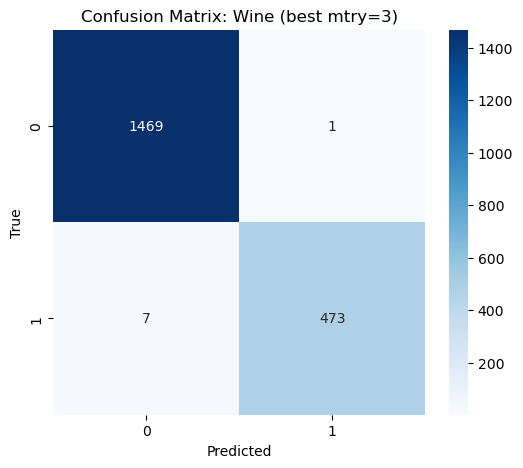

AUC: 0.9924


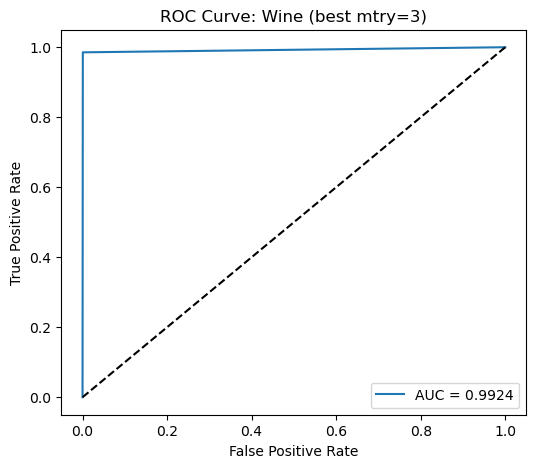

In [ ]:
wine_7030     = all_splits["7030"]["wine"]

results = Tree_Training_Testing(wine_3070)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Retrain using best mtry
num_features = wine_7030["X_train"].shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(wine_7030["X_train"].astype(cp.float32), wine_7030["y_train"])

# Predict (keep on GPU)
preds_gpu = best_rf.predict(wine_7030["X_test"].astype(cp.float32))

# Evaluate (GPU arrays)
evaluate_model(preds_gpu, wine_7030["y_test"], title=f"Wine (best mtry={best_mtry})")

## Customer Data

Using Breiman mtry: [1, 2, 4, 8, 16]
Total features: 7

Training RF with mtry=1 → max_features=0.14286
Accuracy=0.6970, AUC=0.7672

Training RF with mtry=2 → max_features=0.28571
Accuracy=0.6904, AUC=0.7714

Training RF with mtry=4 → max_features=0.57143
Accuracy=0.6937, AUC=0.7687

Training RF with mtry=8 → max_features=1.00000
Accuracy=0.6921, AUC=0.7593

Training RF with mtry=16 → max_features=1.00000
Accuracy=0.6921, AUC=0.7593
Best mtry: 1

=== Customer (best mtry=1) ===
Accuracy: 0.6970

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.74      0.69       274
           1       0.75      0.66      0.71       330

    accuracy                           0.70       604
   macro avg       0.70      0.70      0.70       604
weighted avg       0.70      0.70      0.70       604



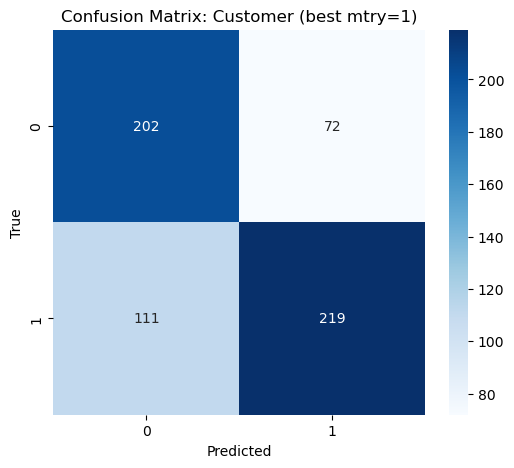

AUC: 0.7004


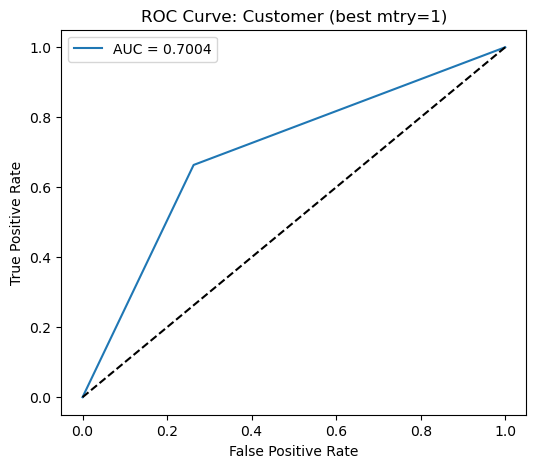

In [ ]:

customer_7030 = all_splits["7030"]["customer"]
X_train = customer_7030["X_train"].astype(cp.float32)
X_test = customer_7030["X_test"].astype(cp.float32)
y_train = customer_7030["y_train"]

# Step 1: Hyperparameter sweep (mtry)
results = Tree_Training_Testing(customer_7030)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Step 2: Fit best RF using scaled mtry for cuML
num_features = X_train.shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(X_train, y_train)

# Step 3: Predict (keep on GPU)
preds_gpu = best_rf.predict(X_test)

# Step 4: Evaluate (GPU arrays)
evaluate_model(preds_gpu, customer_7030["y_test"], title=f"Customer (best mtry={best_mtry})")

## Cup98

Train class distribution: (array([0, 1], dtype=int32), array([63398,  3390]))
Test class distribution: (array([0, 1], dtype=int32), array([27171,  1453]))
Using Breiman mtry: [29, 58, 116, 232, 464]
Total features: 3451

Training RF with mtry=29 → max_features=0.00840
Accuracy=0.9492, AUC=0.5736

Training RF with mtry=58 → max_features=0.01681
Accuracy=0.9492, AUC=0.5741

Training RF with mtry=116 → max_features=0.03361
Accuracy=0.9492, AUC=0.5790

Training RF with mtry=232 → max_features=0.06723
Accuracy=0.9492, AUC=0.5740

Training RF with mtry=464 → max_features=0.13445
Accuracy=0.9492, AUC=0.5737
Best mtry: 29

Best threshold from PR-curve: 0.057752382

Confusion Matrix:
[[17967  9204]
 [  803   650]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     27171
           1       0.07      0.45      0.11      1453

    accuracy                           0.65     28624
   macro avg       0.51      0.55      0.45

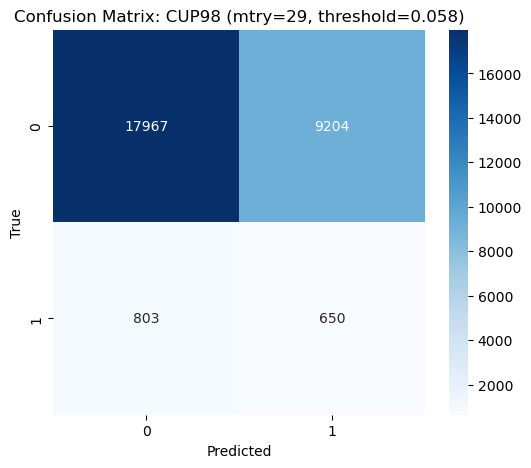

AUC: 0.5543


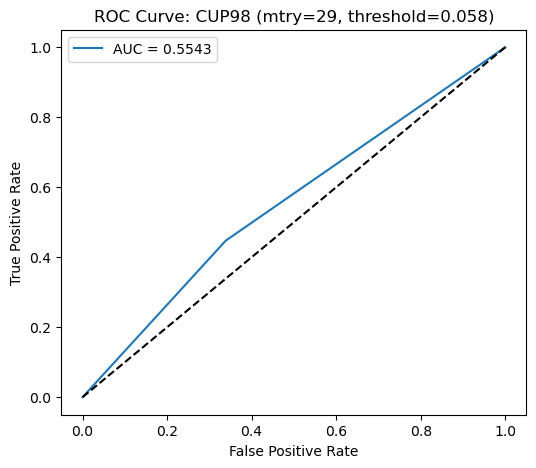

In [ ]:


cup98_7030    = all_splits["7030"]["cup98"]

X_train_dense = to_gpu_dense(cup98_7030["X_train"]).astype(cp.float32)
X_test_dense  = to_gpu_dense(cup98_7030["X_test"]).astype(cp.float32)

y_train = cp.asarray(cup98_7030["y_train"].to_numpy(), dtype=cp.int32)
y_test  = cp.asarray(cup98_7030["y_test"].to_numpy(), dtype=cp.int32)

cup98_data_dense = {
    "X_train": X_train_dense,
    "y_train": y_train,
    "X_test": X_test_dense,
    "y_test": y_test,
}

print("Train class distribution:", cp.unique(y_train, return_counts=True))
print("Test class distribution:", cp.unique(y_test, return_counts=True))

try:
    results = Tree_Training_Testing(cup98_data_dense)
    best_mtry = max(results, key=results.get)
except:
    best_mtry = int(np.sqrt(X_train_dense.shape[1]))
    print(f"Using fallback mtry={best_mtry}")

print("Best mtry:", best_mtry)


num_features = X_train_dense.shape[1]
max_feat_fraction = min(1.0, best_mtry / num_features)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=100,          # leave very big for unlimited
    max_features=max_feat_fraction,
    n_streams=8
)

best_rf.fit(X_train_dense, y_train)

probs_gpu = best_rf.predict_proba(X_test_dense)[:, 1]
probs_cpu = cp.asnumpy(probs_gpu)
y_test_cpu = cp.asnumpy(y_test)


prec, rec, thr = precision_recall_curve(y_test_cpu, probs_cpu)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thr[best_idx]

print("\nBest threshold from PR-curve:", best_threshold)

# Apply threshold
final_preds = (probs_gpu > best_threshold).astype(cp.int32)

print("\nConfusion Matrix:")
print(conf_matrix := confusion_matrix(y_test_cpu, cp.asnumpy(final_preds)))

print("\nClassification Report:")
print(classification_report(y_test_cpu, cp.asnumpy(final_preds)))

evaluate_model(final_preds, y_test, 
               title=f"CUP98 (mtry={best_mtry}, threshold={best_threshold:.3f})")



# 50 50 Split

## wine

Using Breiman mtry: [1, 3, 6, 12, 24]
Total features: 12

Training RF with mtry=1 → max_features=0.08333
Accuracy=0.9910, AUC=0.9980

Training RF with mtry=3 → max_features=0.25000
Accuracy=0.9930, AUC=0.9974

Training RF with mtry=6 → max_features=0.50000
Accuracy=0.9925, AUC=0.9981

Training RF with mtry=12 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963

Training RF with mtry=24 → max_features=1.00000
Accuracy=0.9868, AUC=0.9963
Best mtry: 3

=== Wine (best mtry=3) ===
Accuracy: 0.9948

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2449
           1       1.00      0.98      0.99       800

    accuracy                           0.99      3249
   macro avg       1.00      0.99      0.99      3249
weighted avg       0.99      0.99      0.99      3249



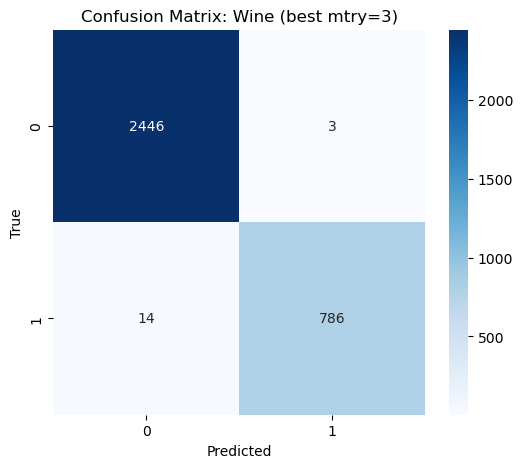

AUC: 0.9906


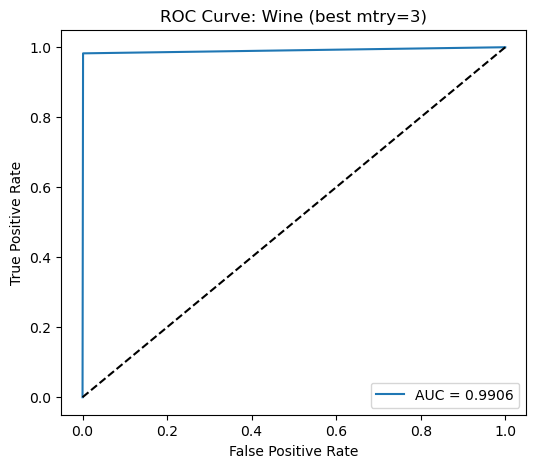

In [ ]:
wine_5050     = all_splits["5050"]["wine"]

results = Tree_Training_Testing(wine_3070)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Retrain using best mtry
num_features = wine_5050["X_train"].shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(wine_5050["X_train"].astype(cp.float32), wine_5050["y_train"])

# Predict (keep on GPU)
preds_gpu = best_rf.predict(wine_5050["X_test"].astype(cp.float32))

# Evaluate (GPU arrays)
evaluate_model(preds_gpu, wine_5050["y_test"], title=f"Wine (best mtry={best_mtry})")

## Customer

Using Breiman mtry: [1, 2, 4, 8, 16]
Total features: 7

Training RF with mtry=1 → max_features=0.14286
Accuracy=0.7001, AUC=0.7637

Training RF with mtry=2 → max_features=0.28571
Accuracy=0.6971, AUC=0.7585

Training RF with mtry=4 → max_features=0.57143
Accuracy=0.6912, AUC=0.7576

Training RF with mtry=8 → max_features=1.00000
Accuracy=0.6922, AUC=0.7478

Training RF with mtry=16 → max_features=1.00000
Accuracy=0.6922, AUC=0.7478
Best mtry: 1

=== Customer (best mtry=1) ===
Accuracy: 0.7001

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.74      0.69       457
           1       0.76      0.67      0.71       550

    accuracy                           0.70      1007
   macro avg       0.70      0.70      0.70      1007
weighted avg       0.71      0.70      0.70      1007



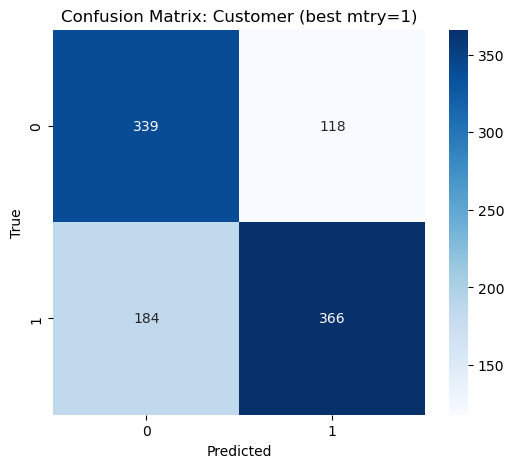

AUC: 0.7036


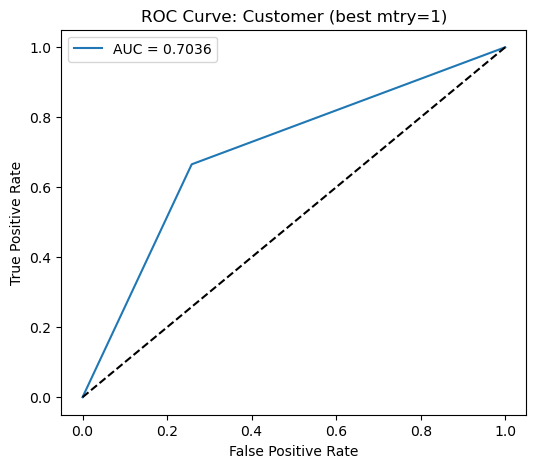

In [ ]:

customer_5050 = all_splits["5050"]["customer"]


X_train = customer_5050["X_train"].astype(cp.float32)
X_test = customer_5050["X_test"].astype(cp.float32)
y_train = customer_5050["y_train"]

# Step 1: Hyperparameter sweep (mtry)
results = Tree_Training_Testing(customer_5050)
best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Step 2: Fit best RF using scaled mtry for cuML
num_features = X_train.shape[1]
max_feat_fraction = best_mtry / num_features
max_feat_fraction = min(1.0, max_feat_fraction)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=50,
    max_features=max_feat_fraction,
    n_streams=8
)
best_rf.fit(X_train, y_train)

# Step 3: Predict (keep on GPU)
preds_gpu = best_rf.predict(X_test)

# Step 4: Evaluate (GPU arrays)
evaluate_model(preds_gpu, customer_5050["y_test"], title=f"Customer (best mtry={best_mtry})")


## cup98

Train class distribution: (array([0, 1], dtype=int32), array([45284,  2421]))
Test class distribution: (array([0, 1], dtype=int32), array([45285,  2422]))
Using Breiman mtry: [29, 58, 116, 232, 464]
Total features: 3451

Training RF with mtry=29 → max_features=0.00840
Accuracy=0.9492, AUC=0.5727

Training RF with mtry=58 → max_features=0.01681
Accuracy=0.9492, AUC=0.5743

Training RF with mtry=116 → max_features=0.03361
Accuracy=0.9492, AUC=0.5771

Training RF with mtry=232 → max_features=0.06723
Accuracy=0.9492, AUC=0.5697

Training RF with mtry=464 → max_features=0.13445
Accuracy=0.9492, AUC=0.5657
Best mtry: 29

Best threshold from PR-curve: 0.059908334

Confusion Matrix:
[[31100 14185]
 [ 1411  1011]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     45285
           1       0.07      0.42      0.11      2422

    accuracy                           0.67     47707
   macro avg       0.51      0.55      0.46

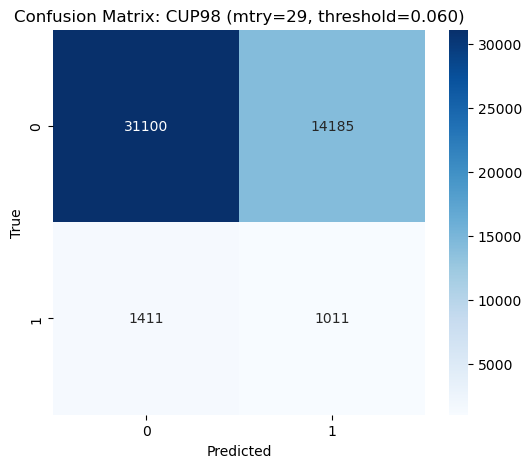

AUC: 0.5521


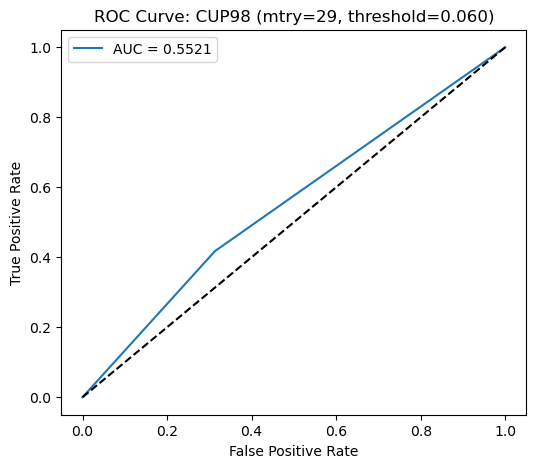

In [ ]:

cup98_5050    = all_splits["5050"]["cup98"]

X_train_dense = to_gpu_dense(cup98_5050["X_train"]).astype(cp.float32)
X_test_dense  = to_gpu_dense(cup98_5050["X_test"]).astype(cp.float32)

y_train = cp.asarray(cup98_5050["y_train"].to_numpy(), dtype=cp.int32)
y_test  = cp.asarray(cup98_5050["y_test"].to_numpy(), dtype=cp.int32)

cup98_data_dense = {
    "X_train": X_train_dense,
    "y_train": y_train,
    "X_test": X_test_dense,
    "y_test": y_test,
}

print("Train class distribution:", cp.unique(y_train, return_counts=True))
print("Test class distribution:", cp.unique(y_test, return_counts=True))

try:
    results = Tree_Training_Testing(cup98_data_dense)
    best_mtry = max(results, key=results.get)
except:
    best_mtry = int(np.sqrt(X_train_dense.shape[1]))
    print(f"Using fallback mtry={best_mtry}")

print("Best mtry:", best_mtry)


num_features = X_train_dense.shape[1]
max_feat_fraction = min(1.0, best_mtry / num_features)

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=100,          # leave very big for unlimited
    max_features=max_feat_fraction,
    n_streams=8
)

best_rf.fit(X_train_dense, y_train)

probs_gpu = best_rf.predict_proba(X_test_dense)[:, 1]
probs_cpu = cp.asnumpy(probs_gpu)
y_test_cpu = cp.asnumpy(y_test)


prec, rec, thr = precision_recall_curve(y_test_cpu, probs_cpu)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thr[best_idx]

print("\nBest threshold from PR-curve:", best_threshold)

# Apply threshold
final_preds = (probs_gpu > best_threshold).astype(cp.int32)

print("\nConfusion Matrix:")
print(conf_matrix := confusion_matrix(y_test_cpu, cp.asnumpy(final_preds)))

print("\nClassification Report:")
print(classification_report(y_test_cpu, cp.asnumpy(final_preds)))

evaluate_model(final_preds, y_test, 
               title=f"CUP98 (mtry={best_mtry}, threshold={best_threshold:.3f})")

